In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import sweetviz as sv
import seaborn as sns

# Fer estadistiques per biomarcador

In [37]:
directorio = "Analizadas"
rangos = [str(x) for x in range(32, 42) if x != 37 and x != 34]
dataframes = []

for numero in rangos:
    nombre_archivo = f'B2400{numero} Genotypes Table.txt'
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    df = pd.read_csv(ruta_archivo, delimiter='\t', skiprows=range(1, 22))
    dataframes.append(df)

Analizadas = pd.concat(dataframes, ignore_index=True)

directorio = "Sin_Analizar"
dataframes = []
for numero in rangos:
    nombre_archivo = f'B2400{numero} sin analizar Genotypes Table.txt'
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    df = pd.read_csv(ruta_archivo, delimiter='\t', skiprows=range(1, 22))
    dataframes.append(df)

NOAnalizadas = pd.concat(dataframes, ignore_index=True)


# NaN

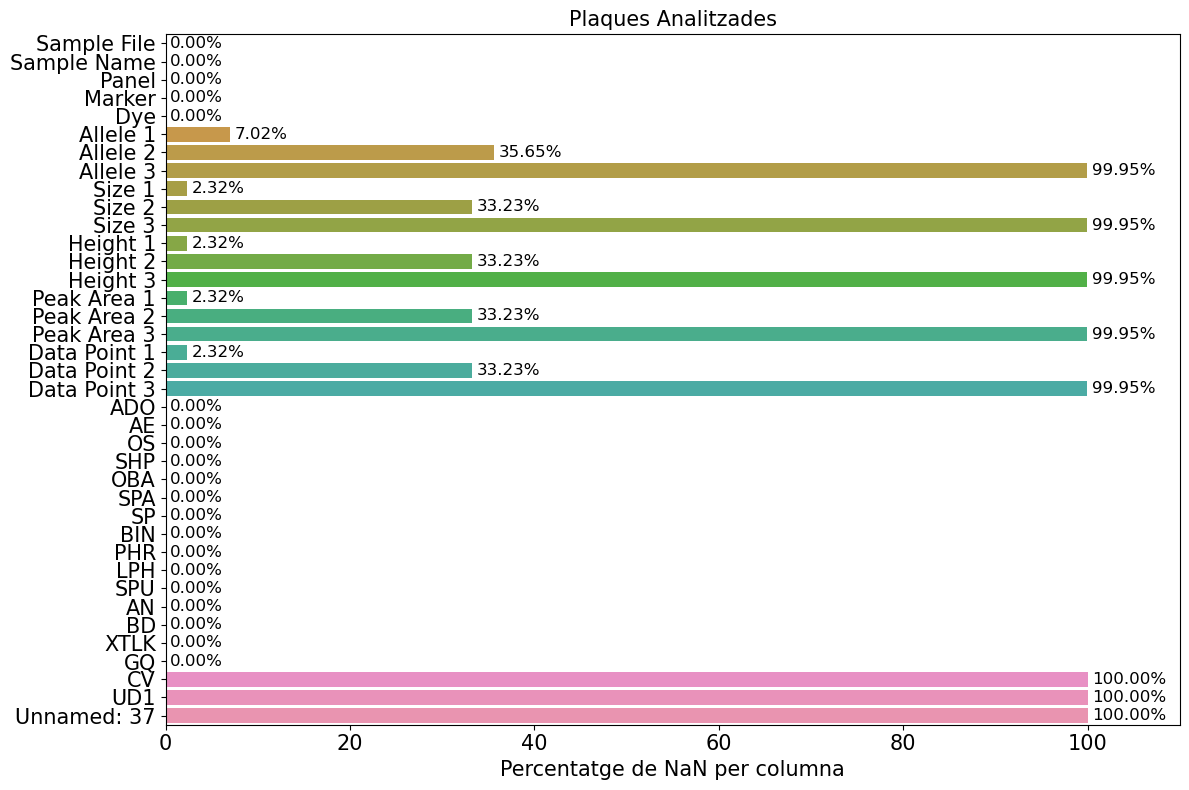

In [57]:
nan_percentage = Analizadas.isna().mean() * 100
nan_percentage = nan_percentage.reset_index()
nan_percentage.columns = ['Column', 'NaN_Percentage']

plt.figure(figsize=(12, 8))
sns.barplot(x='NaN_Percentage', y='Column', data=nan_percentage, orient='h')

# Añadir los porcentajes al final de cada barra
for index, row in nan_percentage.iterrows():
    value = row['NaN_Percentage']
    plt.text(value+0.5, index, f'{value:.2f}%', va='center', ha='left', fontsize=12)  

plt.title('Plaques Analitzades', fontsize=15)
plt.xlabel('Percentatge de NaN per columna',fontsize=15)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(0, 110)  # Ajustar el límite del eje x para que haya espacio para los números
plt.tight_layout()  # Ajustar automáticamente el espaciado para que todo se vea bien
plt.show()

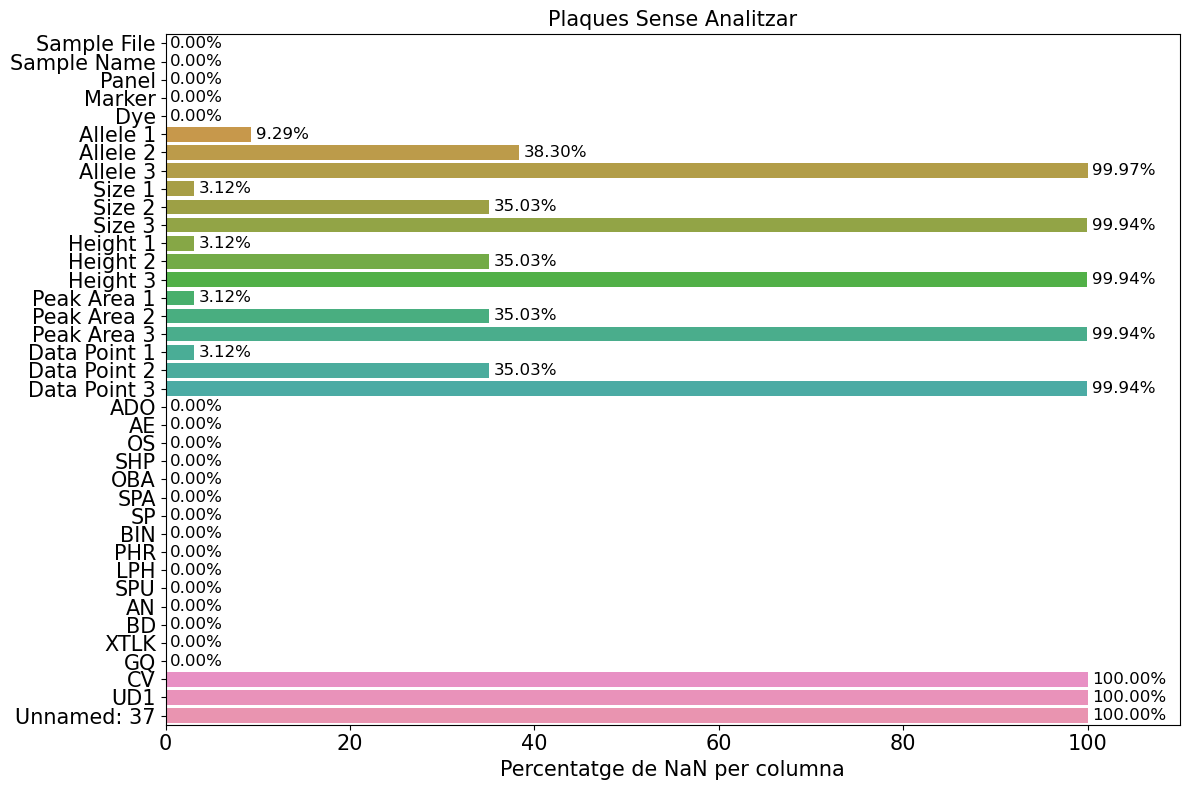

In [56]:
nan_percentage = NOAnalizadas.isna().mean() * 100
nan_percentage = nan_percentage.reset_index()
nan_percentage.columns = ['Column', 'NaN_Percentage']

plt.figure(figsize=(12, 8))
sns.barplot(x='NaN_Percentage', y='Column', data=nan_percentage, orient='h')

# Añadir los porcentajes al final de cada barra
for index, row in nan_percentage.iterrows():
    value = row['NaN_Percentage']
    plt.text(value+0.5, index, f'{value:.2f}%', va='center', ha='left', fontsize=12)  

plt.title('Plaques Sense Analitzar', fontsize=15)
plt.xlabel('Percentatge de NaN per columna',fontsize=15)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlim(0, 110)  # Ajustar el límite del eje x para que haya espacio para los números
plt.tight_layout()  # Ajustar automáticamente el espaciado para que todo se vea bien
plt.show()

# Análisis estadístico

In [40]:
Analizadas['Allele 1'] = pd.to_numeric(Analizadas['Allele 1'], errors='coerce')
Analizadas['Allele 2'] = pd.to_numeric(Analizadas['Allele 2'], errors='coerce')

NOAnalizadas['Allele 1'] = pd.to_numeric(NOAnalizadas['Allele 1'], errors='coerce')
NOAnalizadas['Allele 2'] = pd.to_numeric(NOAnalizadas['Allele 2'], errors='coerce')
NOAnalizadas['Allele 3'] = pd.to_numeric(NOAnalizadas['Allele 3'], errors='coerce')

In [41]:
Analizadas.describe()

,Allele 1,Allele 2,Allele 3,Size 1,Size 2,Size 3,Height 1,Height 2,Height 3,Peak Area 1,...,PHR,LPH,SPU,AN,BD,XTLK,GQ,CV,UD1,Unnamed: 37
count,14840.000000,10270.000000,8.00000,15590.000000,10657.000000,8.000000,15590.000000,10657.000000,8.00000,15590.000000,...,15960.000000,15960.000000,15960.00000,15960.000000,15960.000000,15960.000000,15960.000000,0.0,0.0,0.0
mean,179.304111,183.415871,103.00000,177.597182,182.005890,98.045000,7118.707184,4348.728160,2508.25000,50307.637203,...,-0.809273,-0.337093,-0.33515,-0.259962,-0.337093,-0.336905,0.767208,NaN,NaN,NaN
std,60.632225,59.545077,1.85164,59.478545,58.827249,1.939735,4598.362195,2435.834168,1079.48053,32471.484648,...,1.136287,1.047839,1.04400,1.016328,1.047839,1.047451,0.273562,NaN,NaN,NaN
min,80.000000,89.000000,101.00000,79.180000,84.350000,95.720000,138.000000,89.000000,888.00000,959.000000,...,-4.000000,-4.000000,-4.00000,-4.000000,-4.000000,-4.000000,0.000000,NaN,NaN,NaN
25%,124.000000,128.000000,101.00000,123.680000,127.540000,96.155000,3843.000000,2584.000000,1914.50000,27104.500000,...,-2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.487000,NaN,NaN,NaN
50%,198.000000,170.000000,103.00000,178.755000,200.490000,97.905000,6118.000000,3971.000000,2601.00000,43346.500000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.974000,NaN,NaN,NaN
75%,232.000000,236.000000,105.00000,229.440000,234.040000,100.027500,9212.000000,5663.000000,3169.25000,65532.750000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.974000,NaN,NaN,NaN
max,296.000000,296.000000,105.00000,295.460000,295.560000,100.320000,32666.000000,25414.000000,4095.00000,302132.000000,...,1.000000,0.000000,1.00000,1.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN


In [42]:
NOAnalizadas.describe()

,Allele 1,Allele 2,Allele 3,Size 1,Size 2,Size 3,Height 1,Height 2,Height 3,Peak Area 1,...,PHR,LPH,SPU,AN,BD,XTLK,GQ,CV,UD1,Unnamed: 37
count,14478.000000,9848.000000,4.000000,15462.000000,10369.000000,9.000000,15462.000000,10369.000000,9.000000,15462.000000,...,15960.000000,15960.000000,15960.000000,15960.000000,15960.000000,15960.000000,15960.000000,0.0,0.0,0.0
mean,179.848391,183.584078,118.000000,177.627262,182.172529,162.624444,7143.904605,4477.192304,6037.888889,50503.594684,...,-0.662155,-0.068045,-0.067231,0.012218,-0.068045,-0.067982,0.736490,NaN,NaN,NaN
std,60.322442,59.365329,13.366625,59.366895,58.610879,48.201303,4583.663787,2451.100493,5655.233338,32453.341811,...,1.011010,0.375490,0.376719,0.255354,0.375490,0.375585,0.296119,NaN,NaN,NaN
min,85.000000,89.000000,98.000000,79.180000,84.520000,99.450000,138.000000,89.000000,1144.000000,959.000000,...,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,0.000000,NaN,NaN,NaN
25%,124.000000,129.000000,117.500000,123.690000,127.950000,123.590000,3871.500000,2725.000000,2278.000000,27388.250000,...,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.487000,NaN,NaN,NaN
50%,200.000000,172.000000,124.000000,188.225000,200.490000,143.450000,6134.500000,4055.000000,3413.000000,43472.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.974000,NaN,NaN,NaN
75%,232.000000,236.000000,124.500000,229.430000,234.020000,213.870000,9214.000000,5739.000000,11653.000000,65587.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.974000,NaN,NaN,NaN
max,296.000000,296.000000,126.000000,295.460000,295.560000,214.090000,32666.000000,32370.000000,16439.000000,355296.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN


# Gráficos

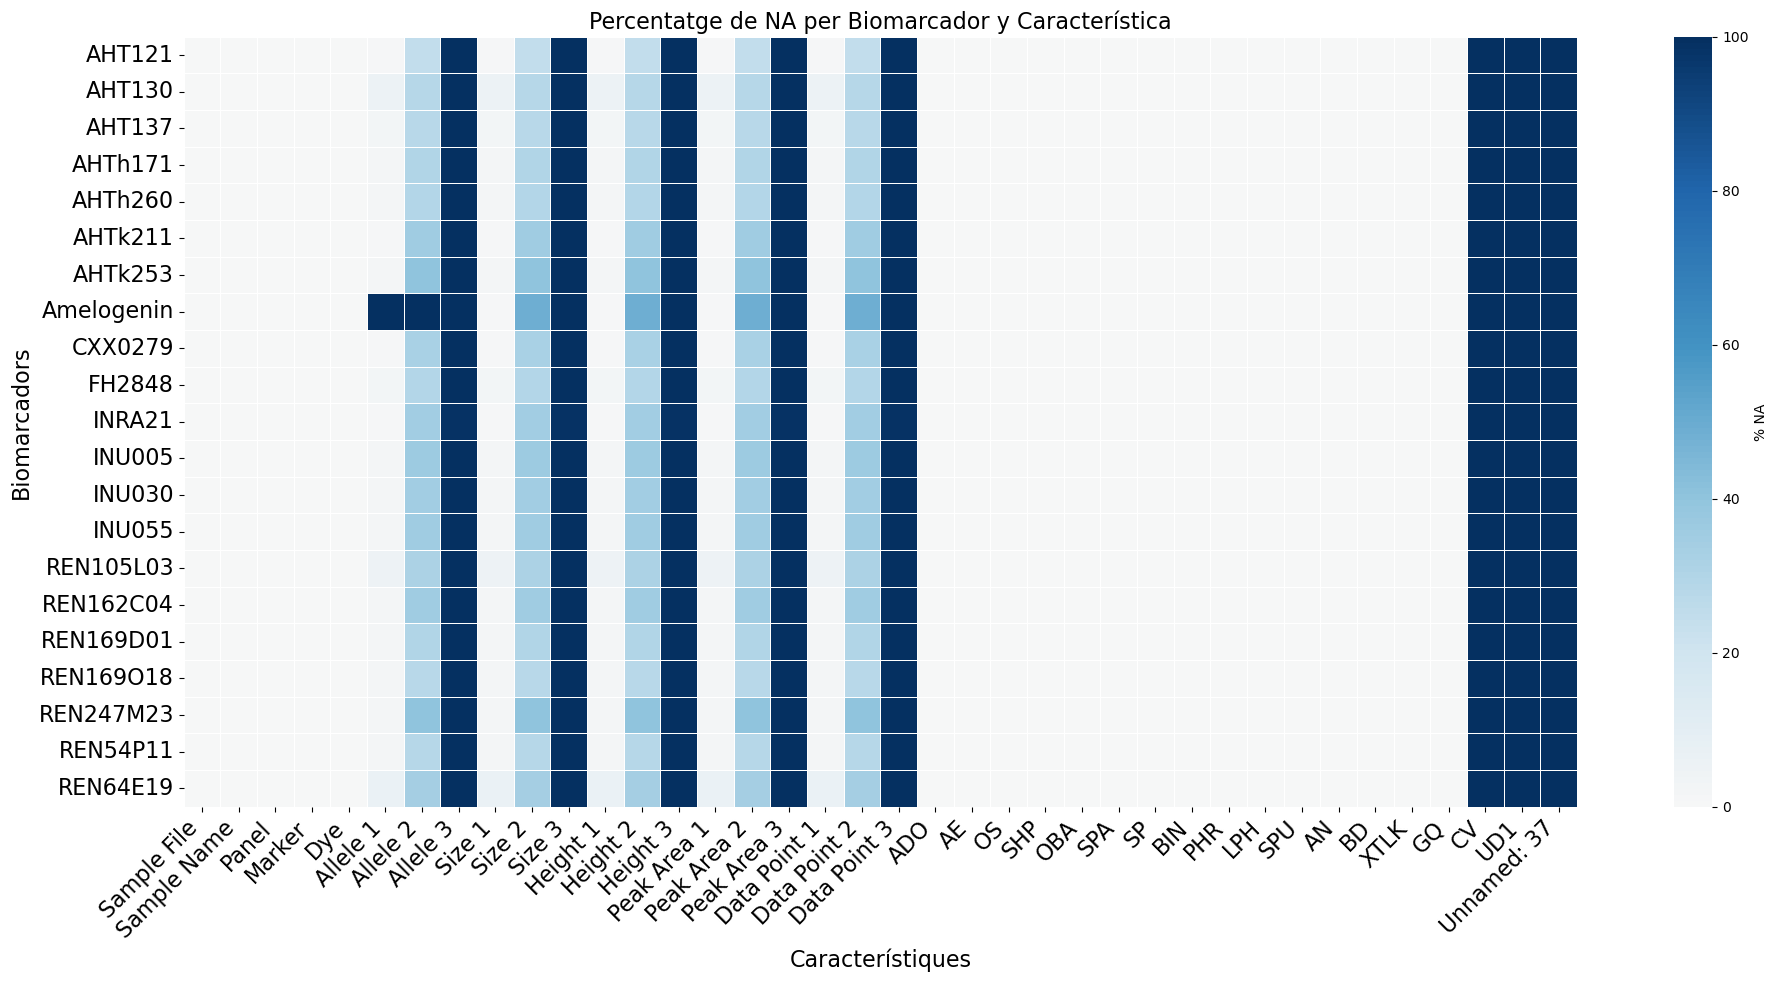

In [58]:
total_counts = Analizadas.groupby('Marker').apply(lambda x: len(x))

# Contar los valores NA por cada biomarcador y característica
na_counts = Analizadas.groupby('Marker').apply(lambda x: x.isna().sum())

# Calcular los porcentajes de valores NA, manejando correctamente las divisiones por cero
na_percentage = (na_counts.div(total_counts, axis=0)) * 100

# Crear el heatmap
plt.figure(figsize=(25, 10)) 
heatmap = sns.heatmap(na_percentage, 
                      annot=False,    
                      cmap="RdBu",    
                      cbar_kws={'label': '% NA'}, 
                      center=0,      
                      linewidths=0.5,
                      square=True)   

heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=16)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=16)

plt.title('Percentatge de NA per Biomarcador y Característica', fontsize=16)
plt.xlabel('Característiques', fontsize=16)
plt.ylabel('Biomarcadors', fontsize=16)
plt.show()

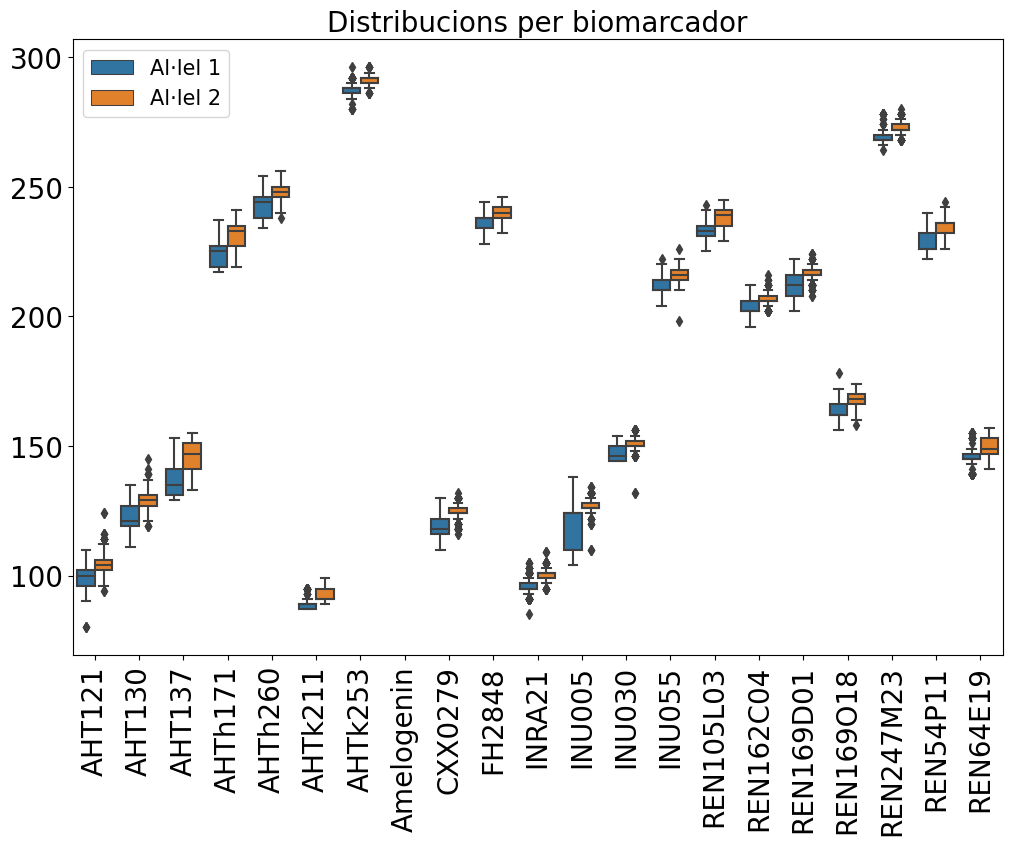

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supongamos que tu DataFrame original se llama `df` y las dos columnas que quieres comparar son 'Columna1' y 'Columna2'

# Reorganizar los datos en formato largo
df_melted = pd.melt(Analizadas, id_vars=['Marker'], value_vars=['Allele 1', 'Allele 2'], 
                    var_name='Columna', value_name='Valor')

plt.figure(figsize=(12, 8))
sns.boxplot(x='Marker', y='Valor', hue="Columna", data=df_melted)
plt.xticks(rotation=90)
plt.tick_params(axis='both', labelsize=20)

# Quitar etiquetas de los ejes
plt.xlabel('')
plt.ylabel('')

# Personalizar la leyenda
plt.legend(title='', fontsize=15, loc='upper right')  # Cambia 'upper right' si prefieres otra posición
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Al·lel 1', 'Al·lel 2'], fontsize=15, loc='upper left')
# Agregar título
plt.title('Distribucions per biomarcador', fontsize=20)

# Mostrar gráfico
plt.show()

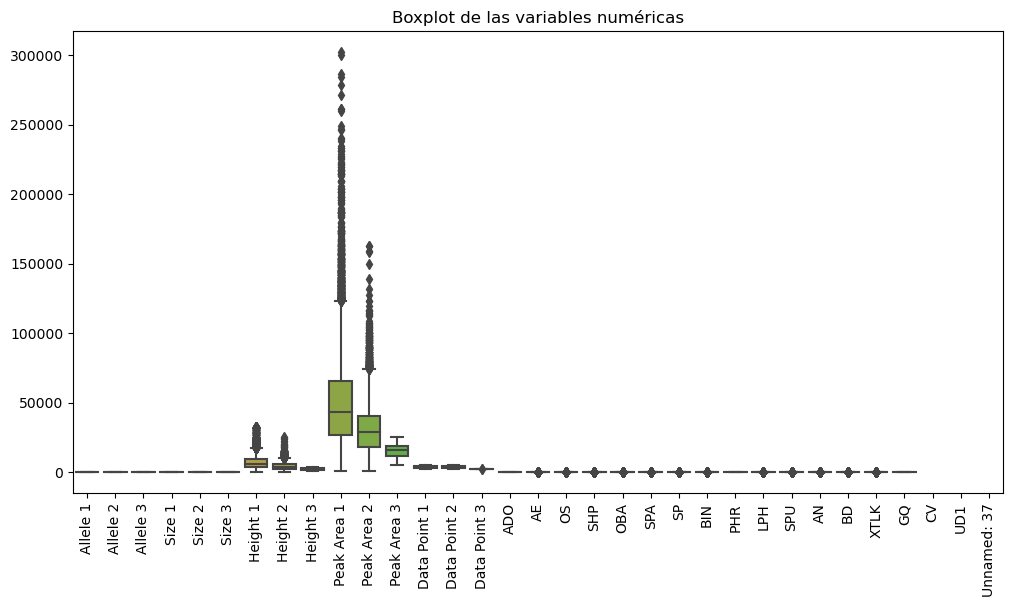

In [51]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=Analizadas)
plt.xticks(rotation=90)
plt.title("Boxplot de las variables numéricas")
plt.show()


In [10]:
# Suponiendo que `Analizadas` es tu DataFrame original y que quieres agrupar por 'Marker'
grouped = Analizadas.groupby('Marker')

# Seleccionar las dos primeras columnas de interés
selected_columns = Analizadas.columns[5:7]

# Aplicar describe() solo a las dos primeras columnas después de agrupar
grouped_selected = grouped[selected_columns].describe()

print(grouped_selected)

           Allele 1                                                           \
              count        mean       std    min    25%    50%    75%    max   
Marker                                                                         
AHT121        750.0   99.261333  4.211178   80.0   96.0  100.0  102.0  110.0   
AHT130        718.0  122.799443  4.130899  111.0  119.0  121.0  127.0  135.0   
AHT137        738.0  136.536585  6.170520  129.0  131.0  135.0  141.0  153.0   
AHTh171       747.0  224.137885  5.289070  217.0  219.0  225.0  227.0  237.0   
AHTh260       748.0  242.970588  3.778923  234.0  238.0  244.0  246.0  254.0   
AHTk211       749.0   88.850467  2.065522   87.0   87.0   89.0   89.0   95.0   
AHTk253       745.0  287.642953  2.078120  280.0  286.0  288.0  288.0  296.0   
Amelogenin      0.0         NaN       NaN    NaN    NaN    NaN    NaN    NaN   
CXX0279       751.0  119.206391  3.505236  110.0  116.0  118.0  122.0  130.0   
FH2848        742.0  236.363881  3.42290

In [11]:
NOAnalizadas = NOAnalizadas.select_dtypes(exclude=['object'])
Analizadas = Analizadas.select_dtypes(exclude=['object'])

Analizadas = Analizadas.applymap(lambda x: int(x) if isinstance(x, bool) else x)
NOAnalizadas = NOAnalizadas.applymap(lambda x: int(x) if isinstance(x, bool) else x)

In [12]:
Analizadas = Analizadas.fillna(-9999)
NOAnalizadas = NOAnalizadas.fillna(-9999)
filtered_df1 = Analizadas.where(Analizadas > -9000)
filtered_df2 = NOAnalizadas.where(NOAnalizadas > -9000)
filtered_df1

,Allele 1,Allele 2,Allele 3,Size 1,Size 2,Size 3,Height 1,Height 2,Height 3,Peak Area 1,...,PHR,LPH,SPU,AN,BD,XTLK,GQ,CV,UD1,Unnamed: 37
0,100.0,106.0,NaN,101.12,107.40,NaN,1516.0,2296.0,NaN,11189.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.347,NaN,NaN,NaN
1,119.0,121.0,NaN,117.47,119.56,NaN,3838.0,1446.0,NaN,23685.0,...,-2.0,-4.0,-4.0,-4.0,-4.0,-4.0,1.000,NaN,NaN,NaN
2,131.0,147.0,NaN,129.36,144.38,NaN,2450.0,2342.0,NaN,15725.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.487,NaN,NaN,NaN
3,219.0,221.0,NaN,217.34,219.33,NaN,5253.0,3088.0,NaN,37965.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.487,NaN,NaN,NaN
4,246.0,248.0,NaN,243.10,245.27,NaN,4652.0,3034.0,NaN,33991.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.974,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15955,216.0,NaN,NaN,210.18,NaN,NaN,6986.0,NaN,NaN,53524.0,...,-2.0,0.0,0.0,0.0,0.0,0.0,0.974,NaN,NaN,NaN
15956,158.0,170.0,NaN,152.59,165.36,NaN,4274.0,2726.0,NaN,31250.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.487,NaN,NaN,NaN
15957,268.0,272.0,NaN,268.36,272.33,NaN,4518.0,3446.0,NaN,38605.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.347,NaN,NaN,NaN
15958,232.0,234.0,NaN,231.88,233.89,NaN,8195.0,5300.0,NaN,57271.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.974,NaN,NaN,NaN


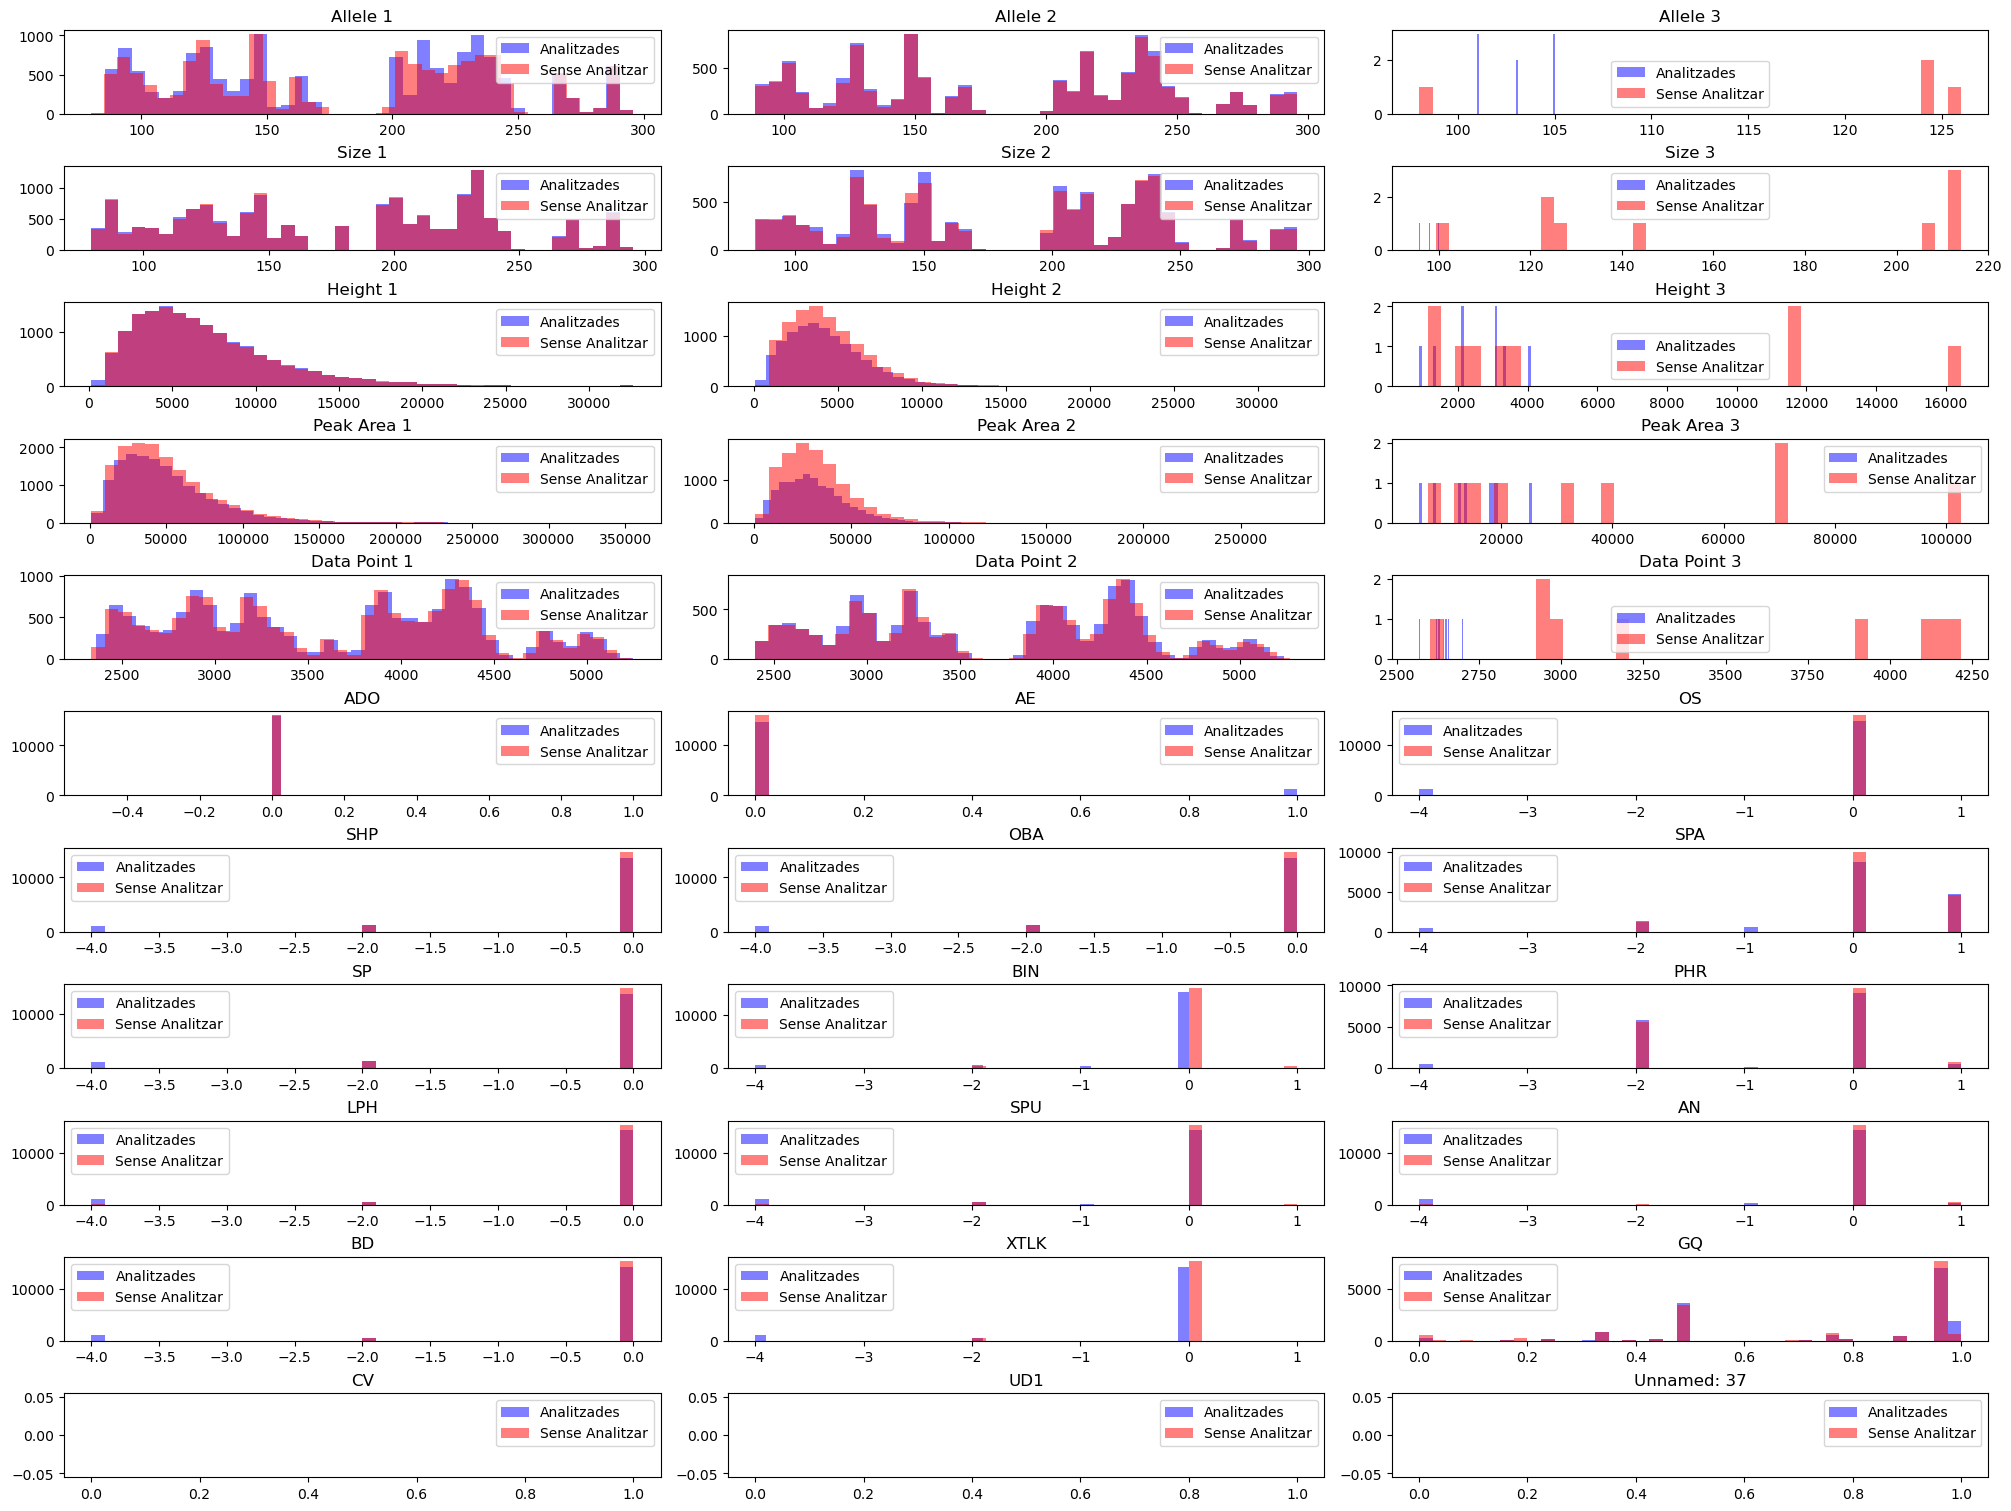

In [16]:
# Listar las columnas que quieres comparar
columns = Analizadas.columns

# Determinar el tamaño de la cuadrícula
n_cols = 3
n_rows = int(np.ceil(len(columns) / n_cols))

# Crear los subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15), constrained_layout=True)
axes = axes.flatten()

# Crear histogramas para cada columna de los DataFrames filtrados
for idx, column in enumerate(columns):
    axes[idx].hist(filtered_df1[column].dropna(), alpha=0.5, label='Analitzades', bins=40, color='blue')
    axes[idx].hist(filtered_df2[column].dropna(), alpha=0.5, label='Sense Analitzar', bins=40, color='red')
    axes[idx].set_title(column)
    axes[idx].legend()

# Eliminar subplots vacíos si hay menos columnas que subplots
for i in range(len(columns), n_rows * n_cols):
    fig.delaxes(axes[i])

plt.show()

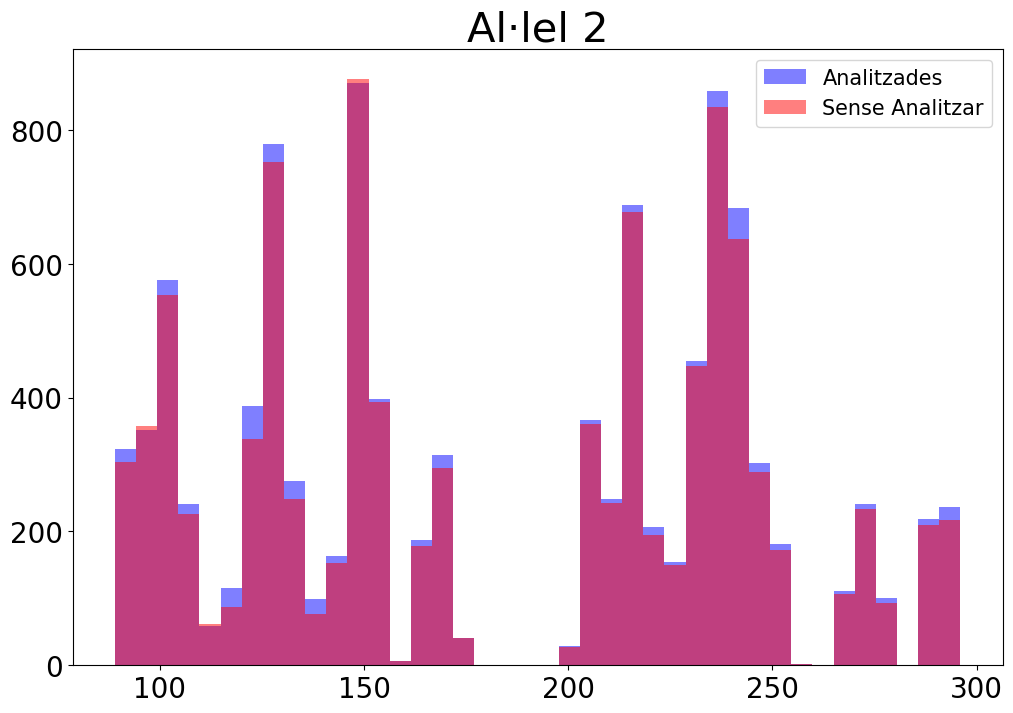

In [29]:
plt.figure(figsize=(12, 8))
plt.hist(filtered_df1["Allele 2"].dropna(), alpha=0.5, label='Analitzades', bins=40, color='blue')
plt.hist(filtered_df2["Allele 2"].dropna(), alpha=0.5, label='Sense Analitzar', bins=40, color='red')
plt.tick_params(axis='both', labelsize=20)
plt.title("Al·lel 2", fontsize=30)
plt.legend(fontsize=15)